In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [4]:
ele_price = pd.read_excel('/Users/geng44/Desktop/project/Average_retail_price_of_electricity.xlsx')

ff_price = pd.read_excel('/Users/geng44/Desktop/project/Average_cost_of_fossil_fuels_for_electricity_generation.xlsx')

ff_receipt = pd.read_excel('/Users/geng44/Desktop/project/Receipts_of_fossil_fuels_by_electricity_plants_for_all_sectors.xlsx')

net_gene = pd.read_excel('/Users/geng44/Desktop/project/Net_generation.xlsx')

In [5]:
ele_price_T = ele_price.T
ele_price_T.columns = ele_price_T.iloc[0]
ele_price_T = ele_price_T[1:]

In [6]:
ff_price_T = ff_price.T
ff_price_T.columns = ff_price_T.iloc[0]
ff_price_T = ff_price_T[1:]

In [7]:
ff_receipt_T = ff_receipt.T
ff_receipt_T.columns = ff_receipt_T.iloc[0]
ff_receipt_T = ff_receipt_T[1:]

In [8]:
net_gene_T = net_gene.T
net_gene_T.columns = net_gene_T.iloc[0]
net_gene_T = net_gene_T[1:]
net_gene_T.fillna(0, inplace=True)

/var/folders/ty/9rmz2lcd2p35hd3wb4_5v6_m0000gs/T/ipykernel_50633/1080020301.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  net_gene_T.fillna(0, inplace=True)


In [9]:
ff_receipt_T

description,coal,bituminous coal,subbituminous coal,lignite coal,petroleum liquids,petroleum coke,natural gas
2008-01-01 00:00:00,87608,37885,42373,5985,4965,628,639424
2008-02-01 00:00:00,84048,36201,41218,5406,3852,422,538625
2008-03-01 00:00:00,87826,39224,42789,4799,3721,630,563326
2008-04-01 00:00:00,86916,38415,42412,4898,6041,612,569441
2008-05-01 00:00:00,88716,40135,41773,5622,4102,516,575650
...,...,...,...,...,...,...,...
2025-08-01 00:00:00,35625,11011,20918,3192,1527,127,1288923
2025-09-01 00:00:00,33684,11084,19635,2601,1039,84,1125996
2025-10-01 00:00:00,34535,11630,19754,2942,1154,133,971380
2025-11-01 00:00:00,33085,10884,18797,3031,1365,86,896400


In [10]:
ff_price_T

description,coal,bituminous coal,subbituminous coal,lignite coal,petroleum liquids,petroleum coke,natural gas
2008-01-01 00:00:00,1.88,2.2,1.55,1.33,14.61,1.62,8.19
2008-02-01 00:00:00,1.89,2.22,1.55,1.37,15.03,1.82,8.58
2008-03-01 00:00:00,1.93,2.25,1.57,1.38,14.67,1.82,9.25
2008-04-01 00:00:00,1.97,2.33,1.57,1.42,14.65,1.79,9.89
2008-05-01 00:00:00,2.04,2.41,1.63,1.37,17.13,1.96,10.73
...,...,...,...,...,...,...,...
2025-08-01 00:00:00,2.41,3.01,2.06,1.76,16.82,2.9,3.17
2025-09-01 00:00:00,2.41,2.97,2.03,1.94,16.25,2.73,3.04
2025-10-01 00:00:00,2.39,2.95,1.99,2.0,16.4,2.66,3.08
2025-11-01 00:00:00,2.39,2.92,2.03,2.08,16.46,2.51,3.89


In [11]:
ele_price_T

description,all sectors,residential,commercial,industrial,transportation,other
2001-01-01 00:00:00,6.75,7.73,7.25,4.73,NaN,6.48
2001-02-01 00:00:00,6.87,8.04,7.51,4.8,NaN,6.94
2001-03-01 00:00:00,7.01,8.32,7.7,4.86,NaN,7.05
2001-04-01 00:00:00,7.02,8.46,7.73,4.87,NaN,7.04
2001-05-01 00:00:00,7.17,8.83,7.77,5.0,NaN,7.14
...,...,...,...,...,...,...
2025-08-01 00:00:00,14.22,17.61,13.93,9.08,14.86,NaN
2025-09-01 00:00:00,14.21,18.08,13.99,9.02,15.25,NaN
2025-10-01 00:00:00,13.66,17.97,13.49,8.65,13.56,NaN
2025-11-01 00:00:00,13.43,17.78,13.19,8.44,13.64,NaN


In [12]:
net_gene_T

description,all fuels (utility-scale),coal,petroleum liquids,petroleum coke,natural gas,other gases,nuclear,conventional hydroelectric,other renewables,wind,all utility-scale solar,geothermal,biomass,wood and wood-derived fuels,other biomass,hydro-electric pumped storage,other,all solar,small-scale solar photovoltaic,all utility-scale solar
2008-01-01 00:00:00,362998.0,182876.0,3131.0,1366.0,72600.0,1063.0,70735.0,20779.0,0,4273.0,16.0,1209.0,4744.0,3338.0,1407.0,-746.0,951.0,0.0,0.0,16.0
2008-02-01 00:00:00,325106.0,166666.0,2438.0,1231.0,60042.0,972.0,65130.0,18789.0,0,3852.0,36.0,1087.0,4374.0,3010.0,1364.0,-451.0,939.0,0.0,0.0,36.0
2008-03-01 00:00:00,324630.0,160743.0,2112.0,1039.0,62171.0,1049.0,64716.0,21669.0,0,4782.0,75.0,1251.0,4596.0,3123.0,1472.0,-553.0,980.0,0.0,0.0,75.0
2008-04-01 00:00:00,305865.0,146983.0,2274.0,1126.0,63046.0,1021.0,57333.0,22234.0,0,5225.0,94.0,1218.0,4433.0,2930.0,1504.0,-132.0,1008.0,0.0,0.0,94.0
2008-05-01 00:00:00,325245.0,154916.0,2343.0,1055.0,62270.0,1044.0,64826.0,27221.0,0,5340.0,99.0,1259.0,4402.0,2927.0,1475.0,-587.0,1057.0,0.0,0.0,99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01 00:00:00,420242.0,69728.0,1019.0,501.0,192894.0,864.0,70705.0,20098.0,0,27307.0,31809.0,1349.0,4037.0,2833.0,1204.0,-568.0,499.0,41128.0,9319.0,31809.0
2025-09-01 00:00:00,368145.0,58302.0,907.0,390.0,167876.0,963.0,65458.0,15285.0,0,25673.0,28149.0,1284.0,3849.0,2713.0,1136.0,-457.0,467.0,36325.0,8176.0,28149.0
2025-10-01 00:00:00,345253.0,54019.0,942.0,437.0,143985.0,1086.0,59222.0,16545.0,0,39534.0,24605.0,1267.0,3628.0,2467.0,1161.0,-513.0,497.0,32195.0,7589.0,24605.0
2025-11-01 00:00:00,334986.0,54490.0,981.0,334.0,131565.0,867.0,63809.0,18415.0,0,40957.0,18592.0,1263.0,3769.0,2581.0,1188.0,-610.0,554.0,24580.0,5987.0,18592.0


In [13]:
# natural gas generation share in electricity production
net_gene_T['ng_share'] = net_gene_T['natural gas']/net_gene_T['all fuels (utility-scale)']
net_gene_T['coal_share'] = net_gene_T['coal']/net_gene_T['all fuels (utility-scale)']
net_gene_T['petroleum_share'] = net_gene_T['petroleum liquids']/net_gene_T['all fuels (utility-scale)']

In [14]:
# electricity price from cents per kwh to dollar per kwh
ele_price_T = ele_price_T/ 100

In [15]:
# fuel price from dollar per million Btu to dollar per kwh
ff_price_T = ff_price_T / 293.07 / 0.9

In [16]:
print(net_gene_T.columns)
print(ff_price_T.columns)

Index(['all fuels (utility-scale)', 'coal', 'petroleum liquids',
       'petroleum coke', 'natural gas', 'other gases', 'nuclear',
       'conventional hydroelectric', 'other renewables', 'wind',
       'all utility-scale solar', 'geothermal', 'biomass',
       'wood and wood-derived fuels', 'other biomass',
       'hydro-electric pumped storage', 'other', 'all solar',
       'small-scale solar photovoltaic', 'all utility-scale solar', 'ng_share',
       'coal_share', 'petroleum_share'],
      dtype='object', name='description')
Index(['coal', 'bituminous coal', 'subbituminous coal', 'lignite coal',
       'petroleum liquids', 'petroleum coke', 'natural gas'],
      dtype='object', name='description')


Scenario Impact Summary:


,Mean Electricity Price Change ($/kWh),Mean Electricity Price Change (%),Mean System Cost Proxy Change,Mean System Cost Proxy Change (%)
Mild gas price spike (+20%),0.001601,1.462152,0.001029,12.829066
Moderate gas price spike (+50%),0.002679,2.448424,0.002572,32.072665
Extreme gas price spike (+100%),0.002655,2.431432,0.005144,64.145330
Mild pipeline disruption,-0.005154,-4.329274,0.000103,1.282907
Moderate pipeline disruption,-0.007196,-6.037399,-0.000463,-5.773080
Severe pipeline disruption,-0.007587,-6.404140,-0.001286,-16.036332
Moderate renewable penetration,-0.006938,-5.827478,-0.001029,-12.829066
High renewable penetration,-0.007988,-6.717438,-0.002057,-25.658132


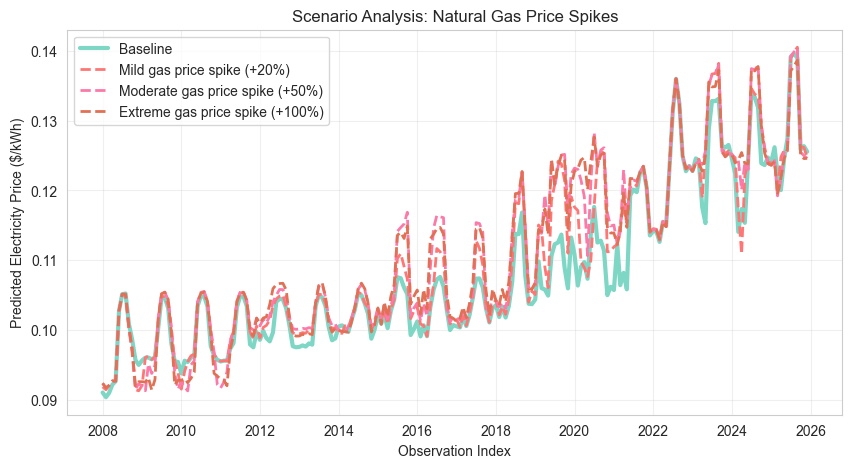

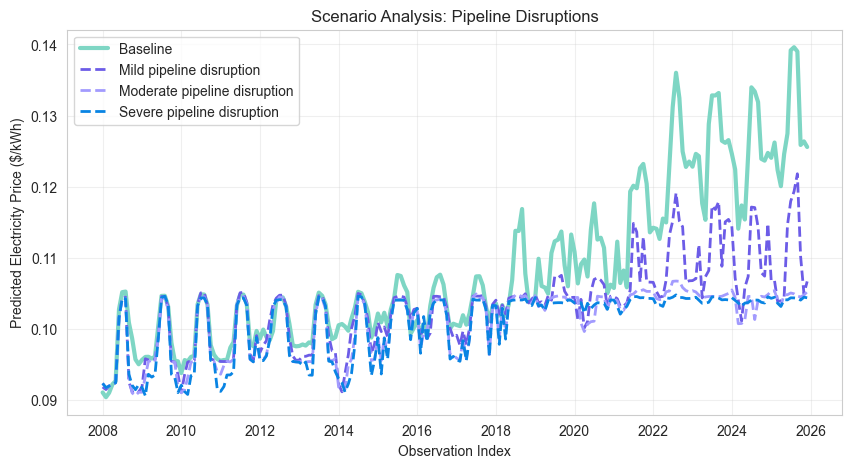

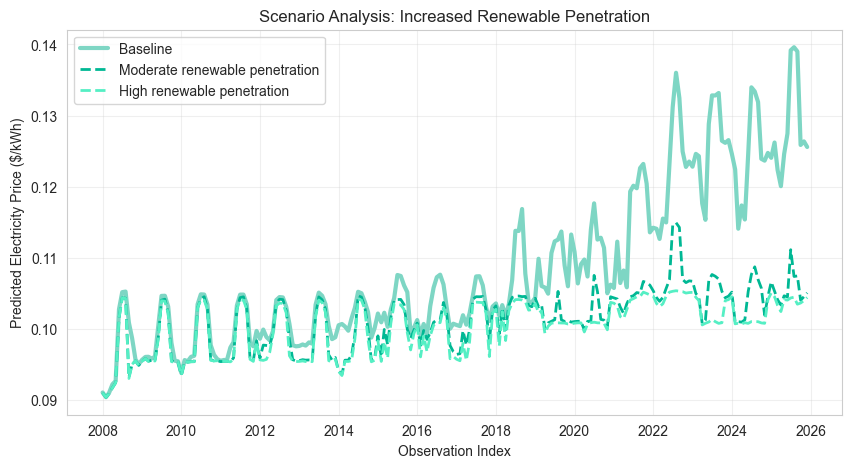

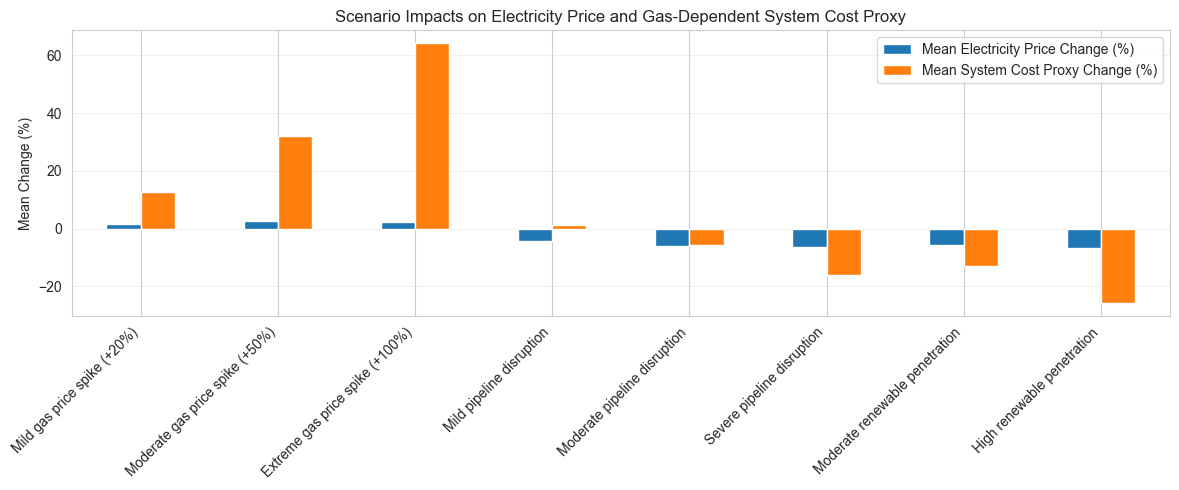

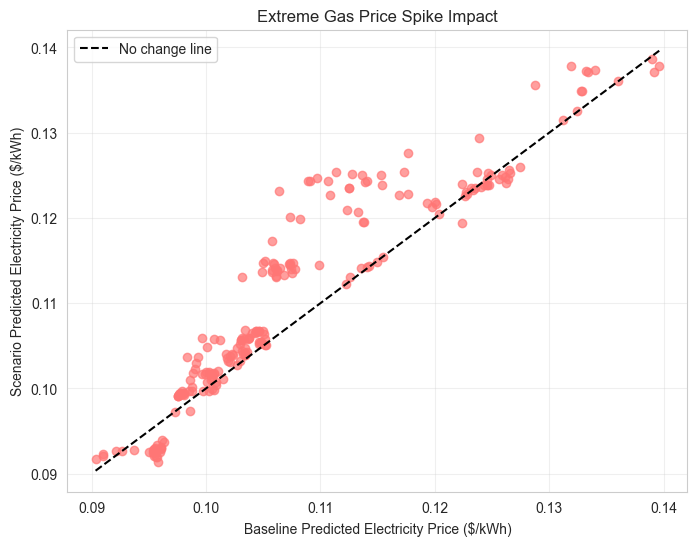

In [17]:
# Build All Sectors Dataset

df_all = pd.DataFrame({
    'gas_price': ff_price_T['natural gas'],
    'coal_price': ff_price_T['coal'],
    'petroleum_price': ff_price_T['petroleum liquids'],
    'ng_share': net_gene_T['ng_share'],
    'coal_share': net_gene_T['coal_share'],
    'petroleum_share': net_gene_T['petroleum_share'],
    'gas_receipt': ff_receipt_T['natural gas'],
    'ele_price': ele_price_T['all sectors']
}).dropna()

X_all = df_all[['gas_price', 'ng_share', 'gas_receipt']]
y_all = df_all['ele_price']

# Train RF Model
model_rf_all = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

model_rf_all.fit(X_all, y_all)

# baseline prediction
baseline_pred = pd.Series(
    model_rf_all.predict(X_all),
    index=df_all.index
)

# baseline gas-dependent system cost proxy
baseline_system_cost = df_all['gas_price'] * df_all['ng_share']

# Scenario Definitions

scenario_definitions = {
    # Natural gas price spikes
    'Mild gas price spike (+20%)': {
        'gas_factor': 1.2,
        'ng_share_factor': 1.0
    },
    'Moderate gas price spike (+50%)': {
        'gas_factor': 1.5,
        'ng_share_factor': 1.0
    },
    'Extreme gas price spike (+100%)': {
        'gas_factor': 2.0,
        'ng_share_factor': 1.0
    },

    # Pipeline disruptions
    'Mild pipeline disruption': {
        'gas_factor': 1.2,
        'ng_share_factor': 0.85
    },
    'Moderate pipeline disruption': {
        'gas_factor': 1.3,
        'ng_share_factor': 0.70
    },
    'Severe pipeline disruption': {
        'gas_factor': 1.5,
        'ng_share_factor': 0.50
    },

    # Increased renewable penetration
    'Moderate renewable penetration': {
        'gas_factor': 1.0,
        'ng_share_factor': 0.80
    },
    'High renewable penetration': {
        'gas_factor': 1.0,
        'ng_share_factor': 0.60
    }
}

# Scenario Simulation

scenario_results = {}
impact_summary = {}

for name, params in scenario_definitions.items():

    df_temp = df_all.copy()

    # apply scenario assumptions
    df_temp['gas_price'] = df_temp['gas_price'] * params['gas_factor']
    df_temp['ng_share'] = df_temp['ng_share'] * params['ng_share_factor']

    X_temp = df_temp[['gas_price', 'ng_share', 'gas_receipt']]

    # predicted electricity price under scenario
    scenario_pred = pd.Series(
        model_rf_all.predict(X_temp),
        index=df_temp.index
    )

    scenario_results[name] = scenario_pred

# Multi-fuel system cost proxy

    baseline_system_cost = (
        df_all['coal_price'] * df_all['coal_share'] +
        df_all['gas_price'] * df_all['ng_share'] +
        df_all['petroleum_price'] * df_all['petroleum_share']
    )

    scenario_system_cost = (
        df_temp['coal_price'] * df_temp['coal_share'] +
        df_temp['gas_price'] * df_temp['ng_share'] +
        df_temp['petroleum_price'] * df_temp['petroleum_share']
    )

    aligned = pd.concat([
        baseline_pred.rename('baseline_price'),
        scenario_pred.rename('scenario_price'),
        baseline_system_cost.rename('baseline_cost_proxy'),
        scenario_system_cost.rename('scenario_cost_proxy')
    ], axis=1).dropna()

    impact_summary[name] = {
        'Mean Electricity Price Change ($/kWh)': (
            aligned['scenario_price'] - aligned['baseline_price']
        ).mean(),

        'Mean Electricity Price Change (%)': (
            (aligned['scenario_price'] - aligned['baseline_price'])
            / aligned['baseline_price'] * 100
        ).mean(),

        'Mean System Cost Proxy Change': (
            aligned['scenario_cost_proxy'] - aligned['baseline_cost_proxy']
        ).mean(),

        'Mean System Cost Proxy Change (%)': (
            (aligned['scenario_cost_proxy'] - aligned['baseline_cost_proxy'])
            / aligned['baseline_cost_proxy'] * 100
        ).mean()
    }

impact_df = pd.DataFrame(impact_summary).T

print("Scenario Impact Summary:")
display(impact_df)

# Plot Function: Scenario Group
def plot_scenario_group(title, scenario_names, colors):
    plt.figure(figsize=(10, 5))

    plt.plot(
        baseline_pred.index,
        baseline_pred,
        label='Baseline',
        color='#7ED6C4',
        linewidth=3
    )

    for i, name in enumerate(scenario_names):
        plt.plot(
            scenario_results[name].index,
            scenario_results[name],
            label=name,
            color=colors[i],
            linestyle='--',
            linewidth=2
        )

    plt.title(title)
    plt.xlabel('Observation Index')
    plt.ylabel('Predicted Electricity Price ($/kWh)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Plot: Natural Gas Price Spikes

plot_scenario_group(
    title='Scenario Analysis: Natural Gas Price Spikes',
    scenario_names=[
        'Mild gas price spike (+20%)',
        'Moderate gas price spike (+50%)',
        'Extreme gas price spike (+100%)'
    ],
    colors=['#FF7675', '#FD79A8', '#E17055']
)


# Plot: Pipeline Disruptions

plot_scenario_group(
    title='Scenario Analysis: Pipeline Disruptions',
    scenario_names=[
        'Mild pipeline disruption',
        'Moderate pipeline disruption',
        'Severe pipeline disruption'
    ],
    colors=['#6C5CE7', '#A29BFE', '#0984E3']
)

# Plot: Increased Renewable Penetration

plot_scenario_group(
    title='Scenario Analysis: Increased Renewable Penetration',
    scenario_names=[
        'Moderate renewable penetration',
        'High renewable penetration'
    ],
    colors=['#00B894', '#55EFC4']
)

# Bar Plot: Price and System Cost Proxy Impacts

impact_df[
    [
        'Mean Electricity Price Change (%)',
        'Mean System Cost Proxy Change (%)'
    ]
].plot(
    kind='bar',
    figsize=(12, 5)
)

plt.ylabel('Mean Change (%)')
plt.title('Scenario Impacts on Electricity Price and Gas-Dependent System Cost Proxy')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Optional: Scatter Comparison for Extreme Gas Spike

plt.figure(figsize=(8, 6))

plt.scatter(
    baseline_pred,
    scenario_results['Extreme gas price spike (+100%)'],
    color='#FF7675',
    alpha=0.7
)

plt.plot(
    [baseline_pred.min(), baseline_pred.max()],
    [baseline_pred.min(), baseline_pred.max()],
    color='black',
    linestyle='--',
    label='No change line'
)

plt.xlabel('Baseline Predicted Electricity Price ($/kWh)')
plt.ylabel('Scenario Predicted Electricity Price ($/kWh)')
plt.title('Extreme Gas Price Spike Impact')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Scenario Impact Summary using ARX model:


,Mean Electricity Price Change ($/kWh),Mean Electricity Price Change (%),Mean System Cost Proxy Change,Mean System Cost Proxy Change (%)
Mild gas price spike (+20%),0.000226,0.210917,0.001023,12.836694
Moderate gas price spike (+50%),0.000565,0.527292,0.002557,32.091736
Extreme gas price spike (+100%),0.001131,1.054584,0.005115,64.183472
Mild pipeline disruption,0.000105,0.101279,0.000102,1.283669
Moderate pipeline disruption,0.000098,0.097100,-0.000460,-5.776512
Severe pipeline disruption,0.000163,0.161833,-0.001279,-16.045868
Moderate renewable penetration,-0.000161,-0.146184,-0.001023,-12.836694
High renewable penetration,-0.000322,-0.292367,-0.002046,-25.673389


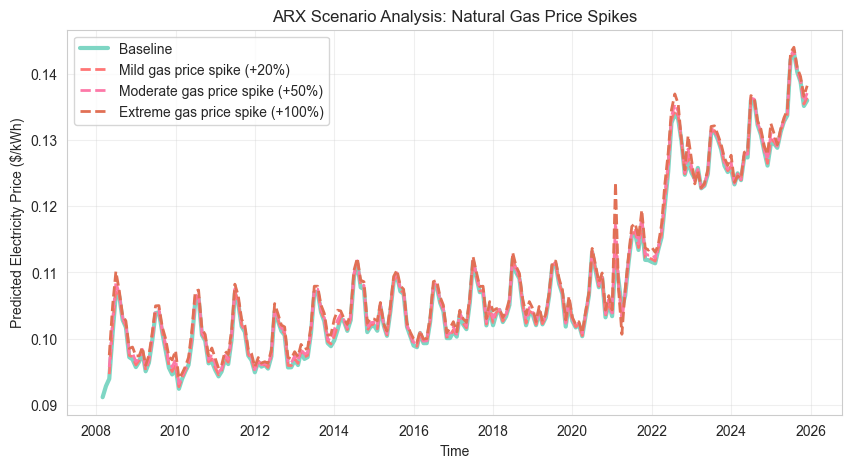

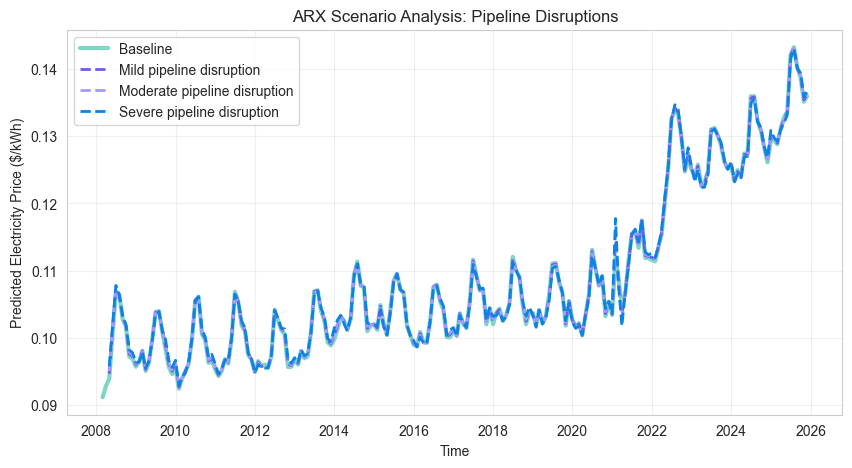

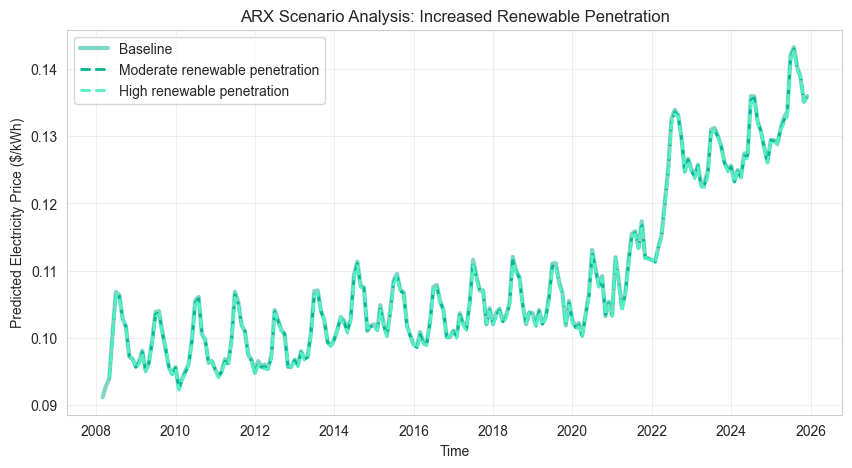

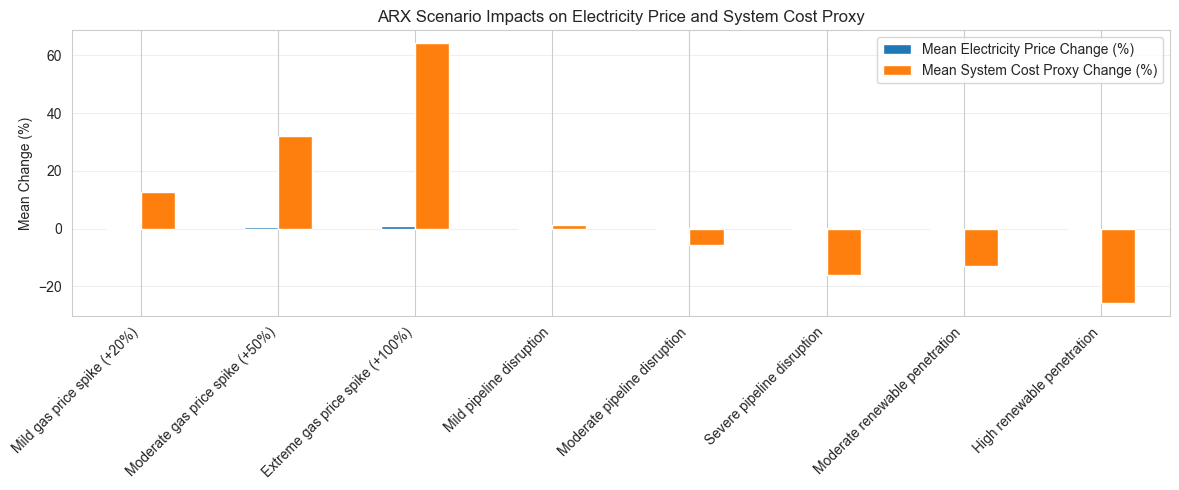

In [18]:
# Build All Sectors Time Series Dataset

df_all = pd.DataFrame({
    'gas_price': ff_price_T['natural gas'],
    'coal_price': ff_price_T['coal'],
    'petroleum_price': ff_price_T['petroleum liquids'],

    'ng_share': net_gene_T['ng_share'],
    'coal_share': net_gene_T['coal_share'],
    'petroleum_share': net_gene_T['petroleum_share'],

    'gas_receipt': ff_receipt_T['natural gas'],
    'ele_price': ele_price_T['all sectors']
}).dropna()

df_all.index = pd.to_datetime(df_all.index, errors='coerce')
df_all = df_all.dropna().sort_index()

# Create Lag Features
df_all['ele_lag1'] = df_all['ele_price'].shift(1)
df_all['gas_lag1'] = df_all['gas_price'].shift(1)
df_all['gas_lag2'] = df_all['gas_price'].shift(2)
df_all['ng_share_lag1'] = df_all['ng_share'].shift(1)
df_all['gas_receipt_lag1'] = df_all['gas_receipt'].shift(1)

df_all = df_all.dropna()

feature_cols = [
    'ele_lag1',
    'gas_price',
    'gas_lag1',
    'gas_lag2',
    'ng_share',
    'ng_share_lag1',
    'gas_receipt',
    'gas_receipt_lag1'
]

X_all = df_all[feature_cols]
y_all = df_all['ele_price']

# Train All Sectors ARX Model

model_arx_all = LinearRegression()
model_arx_all.fit(X_all, y_all)

baseline_pred = pd.Series(
    model_arx_all.predict(X_all),
    index=df_all.index
)

# baseline multi-fuel system cost proxy
baseline_system_cost = (
    df_all['coal_price'] * df_all['coal_share'] +
    df_all['gas_price'] * df_all['ng_share'] +
    df_all['petroleum_price'] * df_all['petroleum_share']
)

# Scenario Definitions

scenario_definitions = {
    'Mild gas price spike (+20%)': {
        'gas_factor': 1.2,
        'ng_share_factor': 1.0
    },
    'Moderate gas price spike (+50%)': {
        'gas_factor': 1.5,
        'ng_share_factor': 1.0
    },
    'Extreme gas price spike (+100%)': {
        'gas_factor': 2.0,
        'ng_share_factor': 1.0
    },

    'Mild pipeline disruption': {
        'gas_factor': 1.2,
        'ng_share_factor': 0.85
    },
    'Moderate pipeline disruption': {
        'gas_factor': 1.3,
        'ng_share_factor': 0.70
    },
    'Severe pipeline disruption': {
        'gas_factor': 1.5,
        'ng_share_factor': 0.50
    },

    'Moderate renewable penetration': {
        'gas_factor': 1.0,
        'ng_share_factor': 0.80
    },
    'High renewable penetration': {
        'gas_factor': 1.0,
        'ng_share_factor': 0.60
    }
}

# Scenario Simulation Using ARX

scenario_results = {}
impact_summary = {}

for name, params in scenario_definitions.items():

    df_temp = df_all.copy()

    # apply scenario assumptions
    df_temp['gas_price'] = df_temp['gas_price'] * params['gas_factor']
    df_temp['ng_share'] = df_temp['ng_share'] * params['ng_share_factor']

    # recalculate lag features affected by scenario
    df_temp['gas_lag1'] = df_temp['gas_price'].shift(1)
    df_temp['gas_lag2'] = df_temp['gas_price'].shift(2)
    df_temp['ng_share_lag1'] = df_temp['ng_share'].shift(1)

    # keep observed electricity lag and receipt lag unchanged
    df_temp['ele_lag1'] = df_all['ele_lag1']
    df_temp['gas_receipt'] = df_all['gas_receipt']
    df_temp['gas_receipt_lag1'] = df_all['gas_receipt_lag1']

    df_temp = df_temp.dropna()

    X_temp = df_temp[feature_cols]

    scenario_pred = pd.Series(
        model_arx_all.predict(X_temp),
        index=df_temp.index
    )

    scenario_results[name] = scenario_pred

    # multi-fuel system cost proxy
    scenario_system_cost = (
        df_temp['coal_price'] * df_temp['coal_share'] +
        df_temp['gas_price'] * df_temp['ng_share'] +
        df_temp['petroleum_price'] * df_temp['petroleum_share']
    )

    aligned = pd.concat([
        baseline_pred.rename('baseline_price'),
        scenario_pred.rename('scenario_price'),
        baseline_system_cost.rename('baseline_cost_proxy'),
        scenario_system_cost.rename('scenario_cost_proxy')
    ], axis=1).dropna()

    impact_summary[name] = {
        'Mean Electricity Price Change ($/kWh)': (
            aligned['scenario_price'] - aligned['baseline_price']
        ).mean(),

        'Mean Electricity Price Change (%)': (
            (aligned['scenario_price'] - aligned['baseline_price'])
            / aligned['baseline_price'] * 100
        ).mean(),

        'Mean System Cost Proxy Change': (
            aligned['scenario_cost_proxy'] - aligned['baseline_cost_proxy']
        ).mean(),

        'Mean System Cost Proxy Change (%)': (
            (aligned['scenario_cost_proxy'] - aligned['baseline_cost_proxy'])
            / aligned['baseline_cost_proxy'] * 100
        ).mean()
    }

impact_df = pd.DataFrame(impact_summary).T

print("Scenario Impact Summary using ARX model:")
display(impact_df)

# Plot Function
def plot_scenario_group(title, scenario_names, colors):
    plt.figure(figsize=(10, 5))

    plt.plot(
        baseline_pred.index,
        baseline_pred,
        label='Baseline',
        color='#7ED6C4',
        linewidth=3
    )

    for i, name in enumerate(scenario_names):
        plt.plot(
            scenario_results[name].index,
            scenario_results[name],
            label=name,
            color=colors[i],
            linestyle='--',
            linewidth=2
        )

    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Predicted Electricity Price ($/kWh)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# =========================
# 7. Scenario Plots
# =========================

plot_scenario_group(
    title='ARX Scenario Analysis: Natural Gas Price Spikes',
    scenario_names=[
        'Mild gas price spike (+20%)',
        'Moderate gas price spike (+50%)',
        'Extreme gas price spike (+100%)'
    ],
    colors=['#FF7675', '#FD79A8', '#E17055']
)

plot_scenario_group(
    title='ARX Scenario Analysis: Pipeline Disruptions',
    scenario_names=[
        'Mild pipeline disruption',
        'Moderate pipeline disruption',
        'Severe pipeline disruption'
    ],
    colors=['#6C5CE7', '#A29BFE', '#0984E3']
)

plot_scenario_group(
    title='ARX Scenario Analysis: Increased Renewable Penetration',
    scenario_names=[
        'Moderate renewable penetration',
        'High renewable penetration'
    ],
    colors=['#00B894', '#55EFC4']
)

# Bar Plot

impact_df[
    [
        'Mean Electricity Price Change (%)',
        'Mean System Cost Proxy Change (%)'
    ]
].plot(
    kind='bar',
    figsize=(12, 5)
)

plt.ylabel('Mean Change (%)')
plt.title('ARX Scenario Impacts on Electricity Price and System Cost Proxy')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()